In [ ]:
!pip install face_recognition

In [ ]:
!pip install dlib


In [ ]:
from imutils import face_utils
import matplotlib.pyplot as plt
import numpy as np
import argparse
import imutils
import dlib
import cv2

import face_recognition

In [ ]:
def plt_imshow(title='image', img=None, figsize=(8 ,5)):
    plt.figure(figsize=figsize)

    if type(img) == list:
        if type(title) == list:
            titles = title
        else:
            titles = []

            for i in range(len(img)):
                titles.append(title)

        for i in range(len(img)):
            if len(img[i].shape) <= 2:
                rgbImg = cv2.cvtColor(img[i], cv2.COLOR_GRAY2RGB)
            else:
                rgbImg = cv2.cvtColor(img[i], cv2.COLOR_BGR2RGB)

            plt.subplot(1, len(img), i + 1), plt.imshow(rgbImg)
            plt.title(titles[i])
            plt.xticks([]), plt.yticks([])

        plt.show()
    else:
        if len(img.shape) < 3:
            rgbImg = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            rgbImg = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(rgbImg)
        plt.title(title)
        plt.xticks([]), plt.yticks([])
        plt.show()

In [ ]:
# face_landmark_path = 'lib/landmark/shape_predictor_68_face_landmarks.dat'
# predictor = dlib.shape_predictor(face_landmark_path)
detector = dlib.get_frontal_face_detector()
predictor = face_recognition.api.pose_predictor_68_point

NameError: ignored

In [ ]:
image_path = 'lena.jpeg'
org_image = cv2.imread(image_path)
image = org_image.copy()
image = imutils.resize(image, width=500)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

rects = detector(gray, 1)

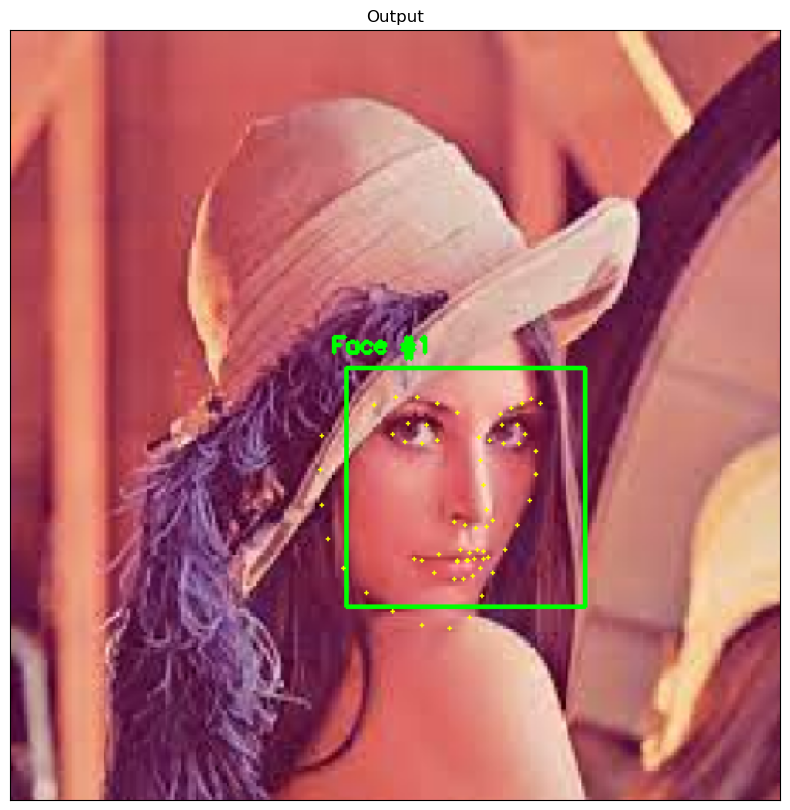

In [ ]:
for (i, rect) in enumerate(rects):
    # 얼굴 영역의 얼굴 랜드마크를 결정한 다음
    # 얼굴 랜드마크(x, y) 좌표를 NumPy Array로 변환합니다.
    shape = predictor(gray, rect)
    shape = face_utils.shape_to_np(shape)

    # dlib의 사각형을 OpenCV bounding box로 변환(x, y, w, h)
    (x, y, w, h) = face_utils.rect_to_bb(rect)
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(image, "Face #{}".format(i + 1), (x - 10, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 얼굴 랜드마크에 포인트를 그립니다.
    for (i, (x, y)) in enumerate(shape):
        cv2.circle(image, (x, y), 1, (0, 255, 255), -1)
        # cv2.putText(image, str(i + 1), (x - 10, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.2, (255, 255, 255), 1)

plt_imshow("Output", image, figsize=(16,10))

In [ ]:
import face_recognition
import cv2
import numpy as np

# This is a demo of running face recognition on live video from your webcam. It's a little more complicated than the
# other example, but it includes some basic performance tweaks to make things run a lot faster:
#   1. Process each video frame at 1/4 resolution (though still display it at full resolution)
#   2. Only detect faces in every other frame of video.

# PLEASE NOTE: This example requires OpenCV (the `cv2` library) to be installed only to read from your webcam.
# OpenCV is *not* required to use the face_recognition library. It's only required if you want to run this
# specific demo. If you have trouble installing it, try any of the other demos that don't require it instead.

# Get a reference to webcam #0 (the default one)
video_capture = cv2.VideoCapture(0)

# Load a sample picture and learn how to recognize it.
sang_image = face_recognition.load_image_file("sang.jpg")
sang_face_encoding = face_recognition.face_encodings(sang_image)[0]

jung_image = face_recognition.load_image_file("jung.jpg")
jung_face_encoding = face_recognition.face_encodings(jung_image)[0]

soo_image = face_recognition.load_image_file("soo.jpg")
soo_face_encoding = face_recognition.face_encodings(soo_image)[0]

# Load a second sample picture and learn how to recognize it.
won_image = face_recognition.load_image_file("won.jpg")
won_face_encoding = face_recognition.face_encodings(won_image)[0]

# Create arrays of known face encodings and their names
known_face_encodings = [
    sang_face_encoding,
    won_face_encoding,
    soo_face_encoding,
    jung_face_encoding
]
known_face_names = [
    "gyu",
    "hye_one",
    "soo",
    "jung"
]

# Initialize some variables
face_locations = []
face_encodings = []
face_names = []
process_this_frame = True

while True:
    # Grab a single frame of video
    ret, frame = video_capture.read()

    # Only process every other frame of video to save time
    if process_this_frame:
        # Resize frame of video to 1/4 size for faster face recognition processing
        small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)

        # Convert the image from BGR color (which OpenCV uses) to RGB color (which face_recognition uses)
        rgb_small_frame = small_frame[:, :, ::-1]
        rgb_small_frame = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)


        # Find all the faces and face encodings in the current frame of video
        face_locations = face_recognition.face_locations(rgb_small_frame)
        face_encodings = face_recognition.face_encodings(rgb_small_frame, face_locations)

        face_names = []
        for face_encoding in face_encodings:
            # See if the face is a match for the known face(s)
            matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
            name = "Unknown"

            # # If a match was found in known_face_encodings, just use the first one.
            # if True in matches:
            #     first_match_index = matches.index(True)
            #     name = known_face_names[first_match_index]

            # Or instead, use the known face with the smallest distance to the new face
            face_distances = face_recognition.face_distance(known_face_encodings, face_encoding)
            best_match_index = np.argmin(face_distances)
            if matches[best_match_index]:
                name = known_face_names[best_match_index]

            face_names.append(name)

    process_this_frame = not process_this_frame


    # Display the results
    for (top, right, bottom, left), name in zip(face_locations, face_names):
        # Scale back up face locations since the frame we detected in was scaled to 1/4 size
        top *= 4
        right *= 4
        bottom *= 4
        left *= 4

        # Draw a box around the face
        cv2.rectangle(frame, (left, top), (right, bottom), (0, 0, 255), 2)

        # Draw a label with a name below the face
        cv2.rectangle(frame, (left, bottom - 35), (right, bottom), (0, 0, 255), cv2.FILLED)
        font = cv2.FONT_HERSHEY_DUPLEX
        cv2.putText(frame, name, (left + 6, bottom - 6), font, 1.0, (255, 255, 255), 1)
    print(name)
    # Display the resulting image
    cv2.imshow('Video', frame)

    # Hit 'q' on the keyboard to quit!
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release handle to the webcam
video_capture.release()
cv2.destroyAllWindows()

hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
hye_one
